In [ ]:
!git clone https://huggingface.co/ctheodoris/Geneformer; cd Geneformer; pip install .

Cloning into 'Geneformer'...
remote: Enumerating objects: 1205, done.
remote: Counting objects: 100% (247/247), done.
remote: Compressing objects: 100% (247/247), done.
remote: Total 1205 (delta 144), reused 0 (delta 0), pack-reused 958 (from 1)
Receiving objects: 100% (1205/1205), 5.77 MiB | 9.04 MiB/s, done.
Resolving deltas: 100% (754/754), done.
Filtering content: 100% (24/24), 3.32 GiB | 50.99 MiB/s, done.
Processing /content/Geneformer
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.1/169.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB

In [ ]:
!pip install anndata scanpy transformers datasets torch h5py cellxgene_census mygene

INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.2/21.2 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.3/84.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 60.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
import json
from tqdm import tqdm
import matplotlib.pyplot as plt
import random
import re
import os
import scipy.sparse
from anndata import AnnData
import gc
import h5py
import scipy.sparse as sparse
from scipy.sparse import csr_matrix, vstack
import anndata as ad
import anndata
import torch
from datasets import Dataset, load_from_disk
from geneformer import TranscriptomeTokenizer

In [ ]:
import requests
from bs4 import BeautifulSoup
import time # Import time for rate limiting
import os # Import os for file path handling

def get_webpage_content(url):
    """
    Fetches the HTML content of a given URL and extracts the brief description.

    Args:
        url (str): The URL of the webpage to fetch.

    Returns:
        str: The extracted brief description, or an error message if the request or parsing fails.
    """
    try:
        # Send a GET request to the URL
        response = requests.get(url, timeout=10) # Added timeout
        # Added a small delay to be polite to the server and avoid being blocked
        time.sleep(0.1)

        # Raise an HTTPError for bad responses (4xx or 5xx)
        response.raise_for_status()

        # Parse the HTML content using BeautifulSoup
        soup = BeautifulSoup(response.text, 'html.parser')

        # Find the <th> tag with the text "Brief description"
        # Then find the next sibling <td> tag to get its text
        brief_description_th = soup.find('th', string='Brief description')
        if brief_description_th:
            brief_description_td = brief_description_th.find_next_sibling('td')
            if brief_description_td:
                return brief_description_td.get_text(strip=True)
            else:
                return "Error: Could not find the <td> tag after 'Brief description'."
        else:
            return "Error: Could not find 'Brief description' header on the page."

    except requests.exceptions.Timeout:
        return f"Error: Request timed out for {url}"
    except requests.exceptions.RequestException as e:
        # Handle any request-related errors (e.g., network issues, invalid URL)
        return f"Error fetching {url}: {e}"
    except Exception as e:
        # Handle any other unexpected errors during parsing
        return f"Error parsing content from {url}: {e}"

def process_gmt_content(gmt_data):
    """
    Reads GMT-like content, extracts URLs, and fetches brief descriptions for each.

    Args:
        gmt_data (str): A string containing the content of a .gmt file.
                        Each line should have gene set name, URL, and then genes,
                        separated by tabs or multiple spaces.
    """
    results = []
    lines = gmt_data.strip().split('\n')
    for line in lines:
        parts = line.strip().split('\t') # Split by tab
        if len(parts) >= 2: # Ensure at least name and URL are present
            gene_set_name = parts[0].strip()
            url = parts[1].strip()
            print(f"Fetching description for: {gene_set_name} (URL: {url})")
            description = get_webpage_content(url)
            results.append(f"{gene_set_name}: {description}")
        else:
            results.append(f"Skipping malformed line: {line}")
    return "\n".join(results)



def parse_pathway_descriptions(pathway_text):
    """
    Parse pathway descriptions from the format:
    PATHWAY_NAME: Description text.

    Args:
        pathway_text: String containing pathway descriptions

    Returns:
        Dictionary mapping pathway names to descriptions
    """
    descriptions = {}

    for line in pathway_text.strip().split('\n'):
        if ':' in line:
            pathway_name, description = line.split(':', 1)
            descriptions[pathway_name.strip()] = description.strip()

    return descriptions


if __name__ == "__main__":
    # Specify the name of your .gmt file
    gmt_filename = "/content/drive/MyDrive/h.all.v2025.1.Hs.symbols.gmt" # You can change this to your file's name

    if os.path.exists(gmt_filename):
          with open(gmt_filename, 'r') as f:
                gmt_file_content = f.read()

          print(f"Starting to process GMT content from {gmt_filename}...")
          processed_results = process_gmt_content(gmt_file_content)
          print("\n--- Processing Complete ---")
          print(processed_results)
          pathway_descriptions = parse_pathway_descriptions(processed_results)
          print("\n--- Pathway Descriptions ---")
          print(pathway_descriptions)
    else:
        print(f"The file {gmt_filename} does not exist.")



Starting to process GMT content from /content/drive/MyDrive/h.all.v2025.1.Hs.symbols.gmt...
Fetching description for: HALLMARK_ADIPOGENESIS (URL: https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_ADIPOGENESIS)
Fetching description for: HALLMARK_ALLOGRAFT_REJECTION (URL: https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_ALLOGRAFT_REJECTION)
Fetching description for: HALLMARK_ANDROGEN_RESPONSE (URL: https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_ANDROGEN_RESPONSE)
Fetching description for: HALLMARK_ANGIOGENESIS (URL: https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_ANGIOGENESIS)
Fetching description for: HALLMARK_APICAL_JUNCTION (URL: https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_APICAL_JUNCTION)
Fetching description for: HALLMARK_APICAL_SURFACE (URL: https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_APICAL_SURFACE)
Fetching description for: HALLMARK_APOPTOSIS (URL: https://www.gsea-msigdb.org/gsea/msig

In [ ]:
# Parse the metadata text from the ontologies
def parse_cell_ontology(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    def extract_info(cell_id, entry):
        """ Extracts relevant fields while handling nested structures. """
        return {
            "id": cell_id,  # Extract the outer dictionary key as the ID
            "name": entry.get("name", ""),
            "definition": entry.get("def", ""),
            "synonyms": entry.get("synonym", []) if isinstance(entry.get("synonym"), list) else [entry.get("synonym")] if entry.get("synonym") else [],
        }

    parsed_data = [extract_info(cell_id, details) for cell_id, details in data.items()]

    return parsed_data

In [ ]:
import os
import numpy as np
import scipy.sparse
import scanpy as sc
from geneformer import TranscriptomeTokenizer

def tokenize_with_geneformer(input_dir, output_dir, dataset_name):
    """
    Tokenize an h5ad file using Geneformer's TranscriptomeTokenizer and save as an Arrow file.
    Includes preprocessing steps to add required ensembl_id and n_counts columns.

    Parameters:
    -----------
    input_dir : str
        Path to the directory with .h5ad files.
    output_dir : str
        Directory to save the tokenized dataset.
    dataset_name : str
        Name of the dataset.

    Returns:
    --------
    str
        Path to the saved tokenized dataset.
    """
    # Default custom attributes
    custom_attrs = {
        #"soma_joinid": "soma_joinid",
        "cell_type": "cell_type",
        "cell_type_ontology_term_id": "cell_type_ontology_term_id",
        #"development_stage": "development_stage",
        "disease": "disease",
        #"disease_ontology_term_id": "disease_ontology_term_id",
        "sex": "sex",
        "tissue": "tissue",
        "tissue_ontology_term_id": "tissue_ontology_term_id",
        #"tissue_general": "tissue_general",
        #"tissue_general_ontology_term_id": "tissue_general_ontology_term_id",
        "pathway1": "pathway1",
        "pathway2": "pathway2",
    }

    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # Initialize Tokenizer
    tk = TranscriptomeTokenizer(custom_attrs)

    # Tokenize the data
    tk.tokenize_data(
        input_dir,
        output_dir,
        dataset_name,
        file_format="h5ad"
    )

    return os.path.join(output_dir, dataset_name)

In [ ]:
import re
from typing import Dict, Optional
from datasets import Dataset

class CellDescriptionGenerator:
    def __init__(self):
        # Age bucketing for consistent groupings
        self.age_buckets = {
            # Embryonic stages (post-fertilization weeks)
            'embryonic_early': list(range(9, 17)),  # 9th-16th week post-fertilization + Carnegie stages
            'embryonic_late': list(range(17, 32)),   # 17th-31st week post-fertilization

            # Postnatal age buckets
            'infant': list(range(0, 2)),           # 0-1 years (newborn, infant stages)
            'toddler': list(range(2, 5)),          # 2-4 years (child stage 1-4 yo)
            'child': list(range(5, 15)),           # 5-14 years (juvenile stage 5-14 yo)
            'adolescent': list(range(15, 20)),     # 15-19 years
            'young_adult': list(range(20, 30)),    # 20-29 years (young adult, third decade)
            'adult': list(range(30, 50)),          # 30-49 years (fourth, fifth decade)
            'middle_aged': list(range(50, 65)),    # 50-64 years (sixth decade)
            'elderly': list(range(65, 80)),        # 65-79 years (seventh, eighth decade)
            'very_elderly': list(range(80, 120))   # 80+ years (ninth decade, 80 year-old and over)
        }

        # Special stage mappings
        self.special_stages = {
            'blastula stage': 'embryonic_early',
            'embryonic stage': 'embryonic_early',
            'organogenesis stage': 'embryonic_early',
            'newborn stage (0-28 days)': 'infant',
            'infant stage': 'infant',
            'child stage (1-4 yo)': 'toddler',
            'juvenile stage (5-14 yo)': 'child',
            'pediatric stage': 'child',
            'young adult stage': 'young_adult',
            'adult stage': 'adult',
            'prime adult stage': 'adult',
            'middle aged stage': 'middle_aged',
            'late adult stage': 'elderly',
            'postnatal stage': 'infant',  # Generic postnatal
            # Decade stages
            'third decade stage': 'young_adult',
            'fourth decade stage': 'adult',
            'fifth decade stage': 'adult',
            'sixth decade stage': 'middle_aged',
            'seventh decade stage': 'elderly',
            'eighth decade stage': 'elderly',
            'ninth decade stage': 'very_elderly',
            # LMP stages (prenatal)
            'fourth LMP month stage': 'embryonic_early',
            'fifth LMP month stage': 'embryonic_early',
            'sixth LMP month stage': 'embryonic_late',
            'seventh LMP month stage': 'embryonic_late',
            'eighth LMP month stage': 'embryonic_late',
            'ninth LMP month stage': 'embryonic_late',
            # Range stage
            '60-79 year-old stage': 'elderly',
            '80 year-old and over stage': 'very_elderly'
        }

        # Bucket descriptions for natural language
        self.bucket_descriptions = {
            'embryonic_early': 'early embryonic stage',
            'embryonic_late': 'late embryonic stage',
            'infant': 'infancy',
            'toddler': 'early childhood',
            'child': 'childhood',
            'adolescent': 'adolescence',
            'young_adult': 'young adulthood',
            'adult': 'adulthood',
            'middle_aged': 'middle age',
            'elderly': 'elderly stage',
            'very_elderly': 'advanced elderly stage'
        }

    def _extract_cell_info(self, cell_type: str) -> tuple:
        """Extract cell name and description from cell_type string"""
        if ',' in cell_type:
            parts = cell_type.split(',', 1)
            cell_name = parts[0].split(':')[-1].strip()
            cell_desc = parts[1].strip()

            # Clean up the description
            cell_desc = re.sub(r'^[Aa]\s+', '', cell_desc)  # Remove leading "A "
            cell_desc = re.sub(r'\s*\.\s*$', '', cell_desc)  # Remove trailing period

            return cell_name, cell_desc
        else:
            cell_name = cell_type.split(':')[-1].strip()
            return cell_name, None

    def _bucket_age(self, age_str: str) -> str:
        """Convert age to bucket category"""
        if not age_str or age_str.lower() == 'unknown':
            return None

        age_str = age_str.lower().strip()

        # Check special stages first
        if age_str in self.special_stages:
            return self.bucket_descriptions[self.special_stages[age_str]]

        # Extract numeric age for year-old stages
        year_match = re.search(r'(\d+)-year-old stage', age_str)
        if year_match:
            age_num = int(year_match.group(1))
            for bucket, age_range in self.age_buckets.items():
                if age_num in age_range:
                    return self.bucket_descriptions[bucket]

        # Extract numeric age for month-old stages (convert to years)
        month_match = re.search(r'(\d+)-month-old stage', age_str)
        if month_match:
            months = int(month_match.group(1))
            age_years = months / 12
            for bucket, age_range in self.age_buckets.items():
                if int(age_years) in age_range:
                    return self.bucket_descriptions[bucket]

        # Handle post-fertilization weeks
        pf_match = re.search(r'(\d+)(?:st|nd|rd|th)?\s*week post-fertilization', age_str)
        if pf_match:
            week = int(pf_match.group(1))
            if week in self.age_buckets['embryonic_early']:
                return self.bucket_descriptions['embryonic_early']
            elif week in self.age_buckets['embryonic_late']:
                return self.bucket_descriptions['embryonic_late']

        # Handle Carnegie stages (all early embryonic)
        if 'carnegie stage' in age_str:
            return self.bucket_descriptions['embryonic_early']

        # Default fallback
        return age_str.replace('stage', '').strip()

    def _should_combine_tissues(self, tissue: str, tissue_general: str) -> bool:
        """Determine if tissue and tissue_general should be combined"""
        if not tissue or not tissue_general:
            return False

        tissue_clean = tissue.lower().strip()
        tissue_general_clean = tissue_general.lower().strip()

        return (tissue_clean == tissue_general_clean or
                tissue_clean in tissue_general_clean or
                tissue_general_clean in tissue_clean)

    def generate_description(self,
                           cell_type: str,
                           tissue: str = "",
                           tissue_general: str = "",
                           disease: str = "normal",
                           sex: Optional[str] = None,
                           age: Optional[str] = None) -> str:
        """Generate natural language description from structured cell data"""

        # Extract cell information (keep ontology info)
        cell_name, cell_description = self._extract_cell_info(cell_type)

        # Extract tissue names - prefer specific tissue, fallback to general
        tissue_name = ""
        if tissue:
            tissue_name = tissue.split(',')[0].split(':')[-1].strip()
        elif tissue_general:
            tissue_name = tissue_general.split(',')[0].split(':')[-1].strip()

        disease_name = disease.split(',')[0].split(':')[-1].strip() if disease else "normal"

        # Start building description
        description = f"This sample consists of a {cell_name}"

        # Add cell type description if available
        if cell_description:
            description += f", {cell_description}"

        description += ". It originates from"

        # Add tissue
        if tissue_name:
            description += f" the {tissue_name} of"

        # Handle disease and sex
        if sex and sex.lower() != 'unknown':
            sex_part = f" {sex.lower()}"
        else:
            sex_part = ""

        if disease_name.lower() not in ['normal', 'healthy', '']:
            # For diseased samples: "of a [sex] with [disease]"
            description += f" a{sex_part} with {disease_name}"
        else:
            # For normal samples: "of a normal [sex]" or "of a [sex]"
            if sex_part:
                description += f" a normal{sex_part}"
            else:
                description += " a normal individual"

        # Add age/developmental stage (bucketed)
        if age and age.lower() != 'unknown':
            bucketed_age = self._bucket_age(age)
            if bucketed_age:
                description += f" during {bucketed_age}"

        return description + "."


def add_natural_description(dataset: Dataset, ontology_dict: dict, pathway_dict: dict = None, batch_size: int = 1000) -> Dataset:
    """Add a natural language description column to a Hugging Face dataset."""

    generator = CellDescriptionGenerator()

    # Identify all ontology columns
    ontology_columns = [col for col in dataset.column_names if col.endswith('_ontology_term_id')]
    base_columns = {col: col.replace('_ontology_term_id', '') for col in ontology_columns}

    def process_batch(examples):
        batch_descriptions = []
        batch_size_actual = len(examples[list(examples.keys())[0]])

        for i in range(batch_size_actual):
            # Get values for this example
            example = {key: values[i] for key, values in examples.items()}

            # Extract ontology-based information
            ontology_info = {}
            for onto_col, base_col in base_columns.items():
                ontology_id = str(example.get(onto_col, '')).upper() if example.get(onto_col) else ""
                base_value = example.get(base_col, '')

                if base_value:  # If we have a base value
                    if ontology_id and ontology_id in ontology_dict:
                        # Use ontology definition if available
                        definition = ontology_dict[ontology_id].get('definition', '')
                        if definition:
                            ontology_info[base_col] = f"{base_value}, {definition}"
                        else:
                            ontology_info[base_col] = base_value
                    else:
                        # Fallback to just the base name
                        ontology_info[base_col] = base_value

            # Generate basic cell description
            description = generator.generate_description(
                cell_type=ontology_info.get('cell_type', ''),
                tissue=ontology_info.get('tissue', ''),
                tissue_general=ontology_info.get('tissue_general', ''),
                disease=ontology_info.get('disease', 'normal'),
                sex=example.get('sex', ''),
                age=example.get('development_stage', '')
            )

            # Add pathway information if available
            if pathway_dict:
                pathways = []

                # Check for pathway1
                pathway1 = example.get('pathway1', '')
                if pathway1 and pathway1 in pathway_dict:
                    pathways.append(pathway_dict[pathway1])

                # Check for pathway2
                pathway2 = example.get('pathway2', '')
                if pathway2 and pathway2 in pathway_dict:
                    pathways.append(pathway_dict[pathway2])

                # Add pathway info naturally
                if len(pathways) == 1:
                    description = description.rstrip('.') + f". This cell is associated with {pathways[0]}"
                elif len(pathways) == 2:
                    description = description.rstrip('.') + f". This cell is associated with {pathways[0]} Additionally, it involves {pathways[1]}"

            batch_descriptions.append(description)

        examples["natural_desc"] = batch_descriptions
        return examples

    print("Adding natural language descriptions to all examples...")
    return dataset.map(
        process_batch,
        batched=True,
        batch_size=batch_size,
        desc="Adding natural descriptions"
    )


In [ ]:
def process_dataset(
    input_dir="/content/drive/MyDrive/cell2text_dataset",
    output_dir="/content/drive/MyDrive/cell2text_dataset_final",
    dataset_name="final_dataset",
    ontology_filepath="/content/drive/MyDrive/obo.json",
    batch_size=1000
):
    print("Tokenizing dataset...")

    #Tokenize the dataset
    tokenize_with_geneformer(input_dir, output_dir, dataset_name)

    print("Loading tokenized dataset...")
    # Load the tokenized dataset
    hf_dataset = load_from_disk(f"{output_dir}/{dataset_name}.dataset")

    print(f"Dataset info: {hf_dataset}")
    print(f"Columns: {hf_dataset.column_names}")
    print(f"Shape: {hf_dataset.shape}")
    print(f"Total number of examples: {len(hf_dataset)}")

    print("Adding structured descriptions...")
    #Load ontology dictionary
    parsed_cells = parse_cell_ontology(ontology_filepath)
    ontology_dict = {
        cell["id"]: {
            "name": cell["name"],
            "definition": cell["definition"],
            "synonym": cell["synonyms"]
        }
        for cell in parsed_cells
    }

    #Add structured descriptions
    hf_dataset = add_natural_description(hf_dataset, ontology_dict, pathway_dict=pathway_descriptions, batch_size=batch_size)

    # Verify all examples have descriptions
    print(f"Examples with struct_desc: {sum(1 for ex in hf_dataset if 'struct_desc' in ex and ex['struct_desc'])}")

    print("Saving final dataset...")
    #Save the final dataset
    final_save_path = os.path.join(output_dir, dataset_name + "_with_descriptions")
    hf_dataset.save_to_disk(final_save_path)
    print(f"Final dataset saved to {final_save_path}")
    print(f"Final dataset size: {len(hf_dataset)} examples")

    return hf_dataset

In [ ]:
import anndata
import numpy as np
import scipy.sparse
import os

def add_required_columns(file_path):
    """
    Adds ensembl_id and n_counts columns to an h5ad file if they don't exist.

    Args:
        file_path (str): Path to the .h5ad file
    """
    if not os.path.exists(file_path):
        print(f"Error: File not found at '{file_path}'")
        return

    # Load the data
    adata = anndata.read_h5ad(file_path)

    # Add ensembl_id column if not present
    if 'ensembl_id' not in adata.var.columns:
        # Try 'feature_id', then 'gene_ids', then use the index
        if 'feature_id' in adata.var.columns:
            adata.var['ensembl_id'] = adata.var['feature_id']
        elif 'gene_ids' in adata.var.columns:
            adata.var['ensembl_id'] = adata.var['gene_ids']
        else:
            print("Warning: Neither 'feature_id' nor 'gene_ids' found in .var. Using index as 'ensembl_id'.")
            adata.var['ensembl_id'] = adata.var.index.astype(str)


    # Add n_counts column if not present
    if 'n_counts' not in adata.obs.columns:
        if scipy.sparse.issparse(adata.X):
            adata.obs["n_counts"] = np.array(adata.X.sum(axis=1)).flatten()
        else:
            adata.obs["n_counts"] = adata.X.sum(axis=1)


    # Save the data
    adata.write_h5ad(file_path)

In [ ]:
#add_required_columns("/content/drive/MyDrive/dominguez/adata_with_pathway_info.h5ad")

In [ ]:
hf_dataset = process_dataset(input_dir="/content/drive/MyDrive/dominguez", dataset_name="dominguez_two_donors")

Tokenizing dataset...
Tokenizing /content/drive/MyDrive/dominguez/adata_with_pathway_info.h5ad


100%|██████████| 59/59 [00:58<00:00,  1.01it/s]
/usr/local/lib/python3.11/dist-packages/geneformer/tokenizer.py:540: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for i in adata.var["ensembl_id_collapsed"][coding_miRNA_loc]
/usr/local/lib/python3.11/dist-packages/geneformer/tokenizer.py:543: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coding_miRNA_ids = adata.var["ensembl_id_collapsed"][coding_miRNA_loc]


/content/drive/MyDrive/dominguez/adata_with_pathway_info.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.
Loading tokenized dataset...
Dataset info: Dataset({
    features: ['input_ids', 'cell_type', 'cell_type_ontology_term_id', 'disease', 'sex', 'tissue', 'tissue_ontology_term_id', 'pathway1', 'pathway2', 'length'],
    num_rows: 29773
})
Columns: ['input_ids', 'cell_type', 'cell_type_ontology_term_id', 'disease', 'sex', 'tissue', 'tissue_ontology_term_id', 'pathway1', 'pathway2', 'length']
Shape: (29773, 10)
Total number of examples: 29773
Adding structured descriptions...
Adding natural language descriptions to all examples...
Examples with struct_desc: 0
Saving final dataset...
Final dataset saved to /content/drive/MyDrive/cell2text_dataset_final/dominguez_two_donors_with_descriptions
Final dataset size: 29773 examples


In [ ]:
print(hf_dataset[42])

{'input_ids': [2, 15988, 18103, 10029, 304, 2342, 10955, 14266, 9398, 18410, 2606, 14643, 9347, 5812, 17764, 5785, 12031, 219, 6877, 6908, 2502, 3362, 10254, 2189, 5865, 6555, 13744, 14362, 9562, 1888, 10964, 2156, 11749, 14419, 18319, 941, 11584, 14865, 2390, 5914, 11109, 7658, 9573, 17617, 18225, 16006, 4067, 13740, 3054, 12295, 911, 944, 438, 2154, 11820, 16, 16245, 7479, 15180, 3872, 7351, 6065, 15098, 10064, 11907, 16376, 4169, 10480, 7292, 19079, 8854, 6603, 17692, 4685, 3736, 141, 10926, 6940, 432, 15928, 14889, 10419, 19133, 12292, 11302, 7001, 8063, 2520, 1719, 913, 896, 6972, 14746, 5621, 9538, 1219, 14227, 7502, 12504, 2921, 16887, 577, 866, 16151, 2292, 1697, 6919, 13457, 15699, 8468, 3495, 5217, 7738, 7983, 4110, 11090, 13765, 16431, 14546, 2737, 17053, 1155, 4158, 16567, 6140, 16364, 8764, 19585, 9672, 11672, 14067, 7149, 5380, 6673, 9528, 16042, 5637, 8333, 9493, 1901, 15307, 2209, 595, 6401, 2718, 6705, 3566, 5082, 5391, 858, 11093, 13134, 1828, 18495, 11345, 3743, 1663

In [ ]:
print(hf_dataset[42]["natural_desc"])

This sample consists of a gamma-delta T cell, T cell that expresses a gamma-delta T cell receptor complex. It originates from the ileum of a normal female. This cell is associated with Genes regulated by NF-kB in response to TNF[GeneID=7124]. Additionally, it involves Genes up-regulated during unfolded protein response, a cellular stress response related to the endoplasmic reticulum.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_length_histogram(hf_dataset):
    """
    Plots a histogram of the 'length' column from a Hugging Face dataset,
    assuming 'length' is directly available.

    Args:
        hf_dataset (datasets.Dataset): The Hugging Face dataset containing
                                       a 'length' column.
    """
    if "length" not in hf_dataset.column_names:
        print("Error: The dataset does not contain a 'length' column.")
        print("Available columns:", hf_dataset.column_names)
        return

    print(f"Extracting 'length' column from {len(hf_dataset)} examples...")
    # Extract the 'length' column. Hugging Face datasets are efficient for this.
    lengths = hf_dataset["length"]

    # Convert to a NumPy array for plotting
    lengths_array = np.array(lengths)

    plt.figure(figsize=(12, 7))
    # Determine a reasonable number of bins. You might want to adjust this.
    # A common approach is sqrt(number of data points) or a fixed number like 50.
    num_bins = min(50, int(np.sqrt(len(lengths_array)))) # Adjust bins dynamically
    plt.hist(lengths_array, bins=num_bins, edgecolor='black', alpha=0.8, color='#6A5ACD')
    plt.title('Distribution of Tokenized Sequence Lengths', fontsize=16)
    plt.xlabel('Sequence Length', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.grid(axis='y', alpha=0.7)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

Extracting 'length' column from 29773 examples...


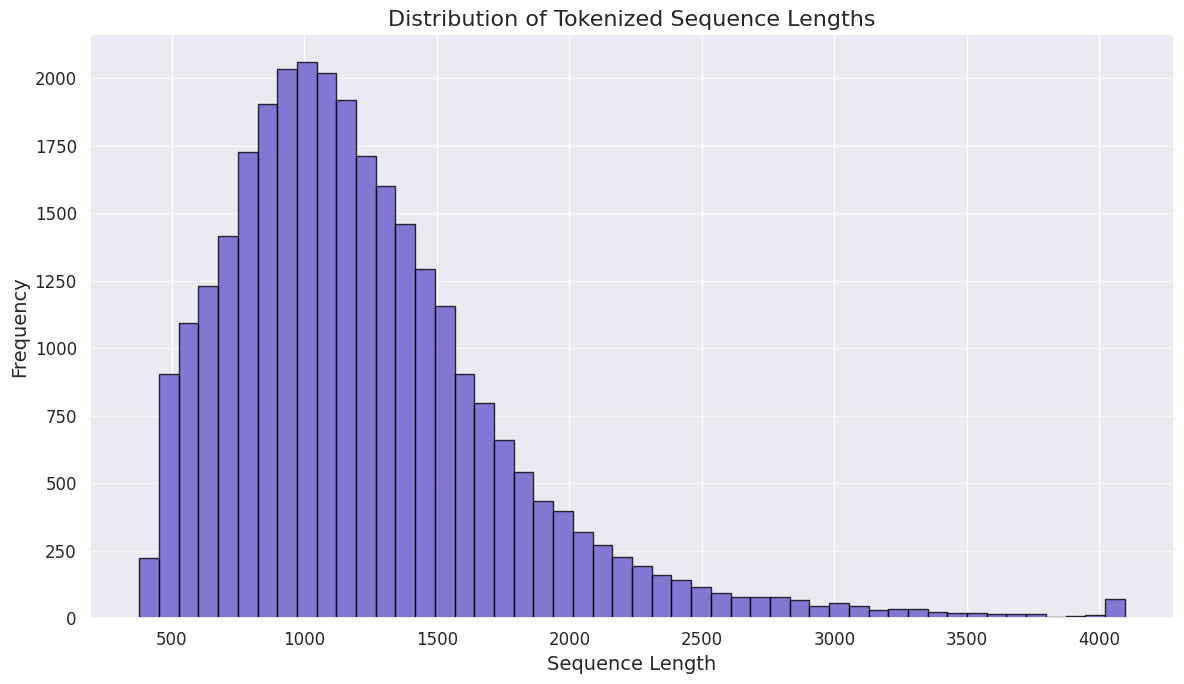

In [ ]:
 plot_length_histogram(hf_dataset)